# nanoGPT — training a real LLM from scratch

Building a full GPT language model, character by character, and training it on tiny_shakespeare until it generates text that actually looks like Shakespeare (badly, but recognizably).

This builds directly on the tokenizer and attention work from `transformer-from-scratch` — same core ideas, this time assembled into something that trains end to end.

Trained end to end on a free Kaggle T4 GPU — the same 5000 steps would have taken hours on CPU instead of about half an hour.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import torch.nn as nn
from torch.nn import functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")
if device == 'cpu':
    print("WARNING: no GPU detected — training will be very slow. On Kaggle, enable a T4 accelerator.")

device: cuda


## Dataset

tiny_shakespeare: about 1MB of Shakespeare's complete works concatenated into one text file. Small enough to train on quickly, structured enough that a working model produces recognizable output (dialogue format, character names, verse-like rhythm).

In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
with open('input.txt', 'w', encoding='utf-8') as f:
    f.write(response.text)

print(f"{len(response.text):,} characters downloaded")
print(response.text[:200])

1,115,394 characters downloaded
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## 1. Character-level tokenizer

The simplest tokenizer possible: every unique character in the text becomes one token. No BPE, no merges, no subword logic — just `char -> id` and `id -> char` lookup tables. This keeps the focus on the model architecture instead of the tokenizer (already covered in lab01_tokenizer of `transformer-from-scratch`).

In [3]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join(itos[i] for i in l)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"vocab_size: {vocab_size}  ->  {''.join(chars)!r}")
print(f"dataset: {len(data):,} tokens  ({len(train_data):,} train / {len(val_data):,} val)")
print(f"round-trip check: {decode(encode('To be or not to be')) == 'To be or not to be'}")

vocab_size: 65  ->  "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
dataset: 1,115,394 tokens  (1,003,854 train / 111,540 val)
round-trip check: True


In [4]:
# Hyperparameters — same architecture as Karpathy's nanoGPT lecture (~10M parameters)
batch_size = 64        # sequences processed in parallel
block_size = 256       # context length in tokens
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
eval_iters = 200
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2

torch.manual_seed(1337)


def get_batch(split):
    """Sample a random batch of (inputs, targets), each shifted by one position."""
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


xb, yb = get_batch('train')
print(f"batch shape: {xb.shape}  (batch_size={batch_size}, block_size={block_size})")

batch shape: torch.Size([64, 256])  (batch_size=64, block_size=256)


## 2. The Transformer block

`LayerNorm -> Multi-Head Attention -> residual -> LayerNorm -> FeedForward -> residual`

Two differences from the attention lab: this attention is **causal** (a token can only attend to earlier positions — a triangular mask blocks the future, otherwise the model could "cheat" by looking at the answer), and there are **residual connections** around each sublayer, which is what makes it possible to stack many blocks without gradients vanishing.

In [5]:
class Head(nn.Module):
    """One causal self-attention head."""

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, _ = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))  # block future positions
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v


class MultiHeadAttention(nn.Module):
    """Multiple causal attention heads in parallel, concatenated and projected back."""

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedFoward(nn.Module):
    """Position-wise MLP: expand to 4x, ReLU, project back down."""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """One Transformer block: attention (communication) + feedforward (computation)."""

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))     # residual around attention
        x = x + self.ffwd(self.ln2(x))   # residual around feedforward
        return x


# Quick shape check
block = Block(n_embd, n_head).to(device)
test_x = torch.randn(2, 10, n_embd).to(device)
print("Block output shape:", block(test_x).shape, "(should match input shape)")

Block output shape: torch.Size([2, 10, 384]) (should match input shape)


## 3. Assembling GPT

Token embedding tells the model *what* each token is. Position embedding tells it *where* each token is in the sequence — without it, attention would have no notion of word order at all (it just looks at all pairs equally). The two are added together, passed through `n_layer` stacked blocks, normalized, then projected to vocabulary logits.

In [6]:
class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        """Autoregressively sample max_new_tokens. Lower temperature = more conservative/repetitive,
        higher temperature = more random/creative."""
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


model = GPTLanguageModel().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params / 1e6:.2f}M parameters")

10.79M parameters


## 4. Training — 5000 steps

Standard training loop: sample a batch, forward pass, backprop, update weights. Every 500 steps we pause to measure the average loss on both train and validation splits (averaged over 200 batches to smooth out noise) and log it for the loss curve.

In [7]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

logged_steps, train_losses, val_losses = [], [], []

for it in range(max_iters):
    if it % eval_interval == 0 or it == max_iters - 1:
        losses = estimate_loss()
        logged_steps.append(it)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        print(f"step {it}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(f"\nFinal train loss: {train_losses[-1]:.4f}")
print(f"Final val loss:   {val_losses[-1]:.4f}")

step 0: train loss 4.2876, val loss 4.2851
step 500: train loss 1.7428, val loss 1.8938
step 1000: train loss 1.4116, val loss 1.6220
step 1500: train loss 1.2801, val loss 1.5437
step 2000: train loss 1.1973, val loss 1.4959
step 2500: train loss 1.1348, val loss 1.4928
step 3000: train loss 1.0795, val loss 1.4875
step 3500: train loss 1.0275, val loss 1.4911
step 4000: train loss 0.9694, val loss 1.5129
step 4500: train loss 0.9166, val loss 1.5313
step 4999: train loss 0.8677, val loss 1.5538

Final train loss: 0.8677
Final val loss:   1.5538


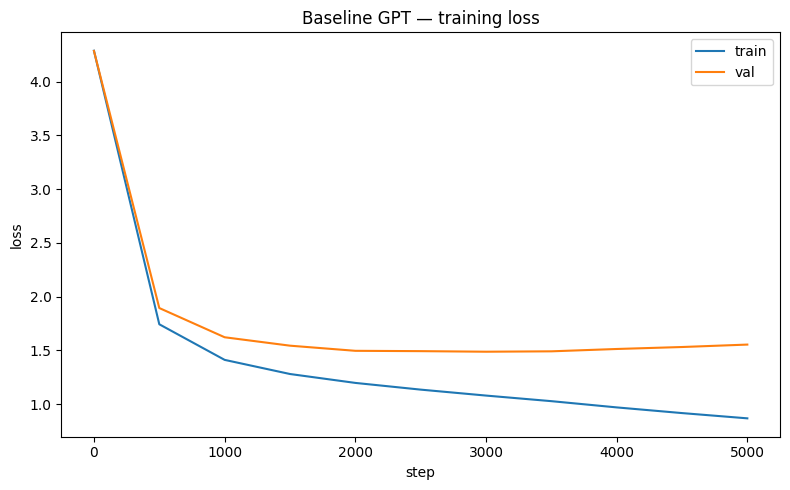

Saved: loss_curve_baseline.png


In [8]:
plt.figure(figsize=(8, 5))
plt.plot(logged_steps, train_losses, label='train')
plt.plot(logged_steps, val_losses, label='val')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Baseline GPT — training loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve_baseline.png', dpi=120)
plt.show()
print("Saved: loss_curve_baseline.png")

## 5. Generating text

Starting from a single newline character, the model generates tokens one at a time, feeding each prediction back in as input for the next step. `temperature=0.8` slightly softens the probability distribution — a bit more variety than always picking the most likely next character, without descending into randomness.

In [9]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = model.generate(context, max_new_tokens=500, temperature=0.8)
print(decode(generated[0].tolist()))


What's her father? 'Be madline; I were come for't:
What, sir, what you offend.

GLOUCESTER:
The curet beauty that fill'd at my career,
Is nine mouths to course in court?
Yet, so I love, and must be of yours!
As thou shalt speak betife more creation.

BIANCA:
Well, you have mine with heer givious time
Fall opers.

DUKE VINCENTIO:
Let me hear your to heart as mine have time
And lame you that have wipt your sheirs.

PARISABELLA:
Your deserty in your brothery what they
May call me to visit the rests


## 6. RoPE — Rotary Position Embedding

So far, position is injected by **adding** a learned position vector to each token embedding, once, at the input. RoPE takes a different approach: instead of adding position information, it **rotates** the query and key vectors inside every attention layer by an angle proportional to their position. The rotation angle differs per pair of dimensions, so nearby positions end up with similar rotations and distant positions with very different ones — the dot product `q @ k` (which is what attention scores are built from) then naturally decays with distance, and generalizes better to sequence lengths not seen during training.

Practically: no more `position_embedding_table`. Instead, `apply_rope` rotates Q and K right before computing attention scores.

In [10]:
def build_rope_cache(seq_len, head_size, device):
    """Precompute the cos/sin rotation angles for each position and each dimension pair."""
    theta = 1.0 / (10000 ** (torch.arange(0, head_size, 2, device=device).float() / head_size))
    pos = torch.arange(seq_len, device=device).float()
    freqs = torch.outer(pos, theta)  # (seq_len, head_size/2)
    return torch.cos(freqs), torch.sin(freqs)


def apply_rope(x, cos, sin):
    """Rotate consecutive dimension pairs of x by the precomputed angles."""
    x1 = x[..., 0::2]
    x2 = x[..., 1::2]
    rotated = torch.zeros_like(x)
    rotated[..., 0::2] = x1 * cos - x2 * sin
    rotated[..., 1::2] = x1 * sin + x2 * cos
    return rotated


class HeadRoPE(nn.Module):
    """Causal self-attention head with RoPE applied to Q and K instead of a position embedding."""

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size

    def forward(self, x):
        B, T, _ = x.shape
        k = self.key(x)
        q = self.query(x)
        cos, sin = build_rope_cache(T, self.head_size, x.device)
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)
        wei = q @ k.transpose(-2, -1) * self.head_size ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v


class MultiHeadAttentionRoPE(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([HeadRoPE(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class BlockRoPE(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttentionRoPE(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModelRoPE(nn.Module):
    """Same as GPTLanguageModel, but no position_embedding_table — position comes from RoPE inside attention."""

    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.blocks = nn.Sequential(*[BlockRoPE(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        x = self.token_embedding_table(idx)
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


model_rope = GPTLanguageModelRoPE().to(device)
n_params_rope = sum(p.numel() for p in model_rope.parameters())
print(f"{n_params_rope / 1e6:.2f}M parameters (vs {n_params / 1e6:.2f}M baseline — RoPE has no position embedding table)")

10.69M parameters (vs 10.79M baseline — RoPE has no position embedding table)


In [11]:
@torch.no_grad()
def estimate_loss_rope():
    out = {}
    model_rope.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model_rope(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model_rope.train()
    return out


max_iters_rope = 2000
eval_interval_rope = 500

optimizer_rope = torch.optim.AdamW(model_rope.parameters(), lr=learning_rate)

logged_steps_rope, train_losses_rope, val_losses_rope = [], [], []

for it in range(max_iters_rope):
    if it % eval_interval_rope == 0 or it == max_iters_rope - 1:
        losses = estimate_loss_rope()
        logged_steps_rope.append(it)
        train_losses_rope.append(losses['train'])
        val_losses_rope.append(losses['val'])
        print(f"step {it}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    _, loss = model_rope(xb, yb)
    optimizer_rope.zero_grad(set_to_none=True)
    loss.backward()
    optimizer_rope.step()

print(f"\nFinal train loss: {train_losses_rope[-1]:.4f}")
print(f"Final val loss:   {val_losses_rope[-1]:.4f}")

step 0: train loss 4.2352, val loss 4.2391
step 500: train loss 1.4801, val loss 1.6721
step 1000: train loss 1.2978, val loss 1.5472
step 1500: train loss 1.2117, val loss 1.4914
step 1999: train loss 1.1482, val loss 1.4787

Final train loss: 1.1482
Final val loss:   1.4787


### Comparing perplexity

Perplexity is `exp(loss)` — roughly "how many characters is the model effectively choosing between, on average, when it's unsure." Lower is better. It's a more intuitive number than raw cross-entropy loss: a perplexity of 5 means the model's uncertainty is comparable to guessing uniformly among 5 characters.

This isn't a perfectly fair comparison (RoPE only trained 2000 steps vs 5000 for the baseline), but it's enough to see whether RoPE is in the right ballpark after fewer steps.

In [12]:
baseline_val_loss = val_losses[-1]
rope_val_loss = val_losses_rope[-1]

print(f"{'Model':<20} {'Steps':<8} {'Val loss':<12} {'Perplexity':<10}")
print(f"{'Baseline (pos emb)':<20} {max_iters:<8} {baseline_val_loss:<12.4f} {math.exp(baseline_val_loss):<10.2f}")
print(f"{'RoPE':<20} {max_iters_rope:<8} {rope_val_loss:<12.4f} {math.exp(rope_val_loss):<10.2f}")

Model                Steps    Val loss     Perplexity
Baseline (pos emb)   5000     1.5538       4.73      
RoPE                 2000     1.4787       4.39      


In [13]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_rope = model_rope.generate(context, max_new_tokens=500, temperature=0.8)
print(decode(generated_rope[0].tolist()))


POMPEY:
I may, thy which is actier.

BRUTUS:
Nay, condition; that as the villain the field of
methinks it be not to sin to the common firs time
he and care and reasons.

Second Servingman:
'tis time the joy of our sovereign to thine hearts
his noble worship.

First Servingman:
Thus is thy requite, 'man.

Clown:
Forsweth nor this.

LUCIO:
An excellant is the poor and the accession he is
the very sound?

First General:
Worthy a poiece, my life. I do beseech you to make
her.

CORIOLANUS:
I would th


## Loss curve GIF

Building the baseline loss curve frame by frame into an animated GIF, for the README.

In [14]:
import imageio.v2 as imageio

frames = []
y_max = max(train_losses + val_losses) * 1.1

for i in range(1, len(logged_steps) + 1):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(logged_steps[:i], train_losses[:i], label='train', marker='o')
    ax.plot(logged_steps[:i], val_losses[:i], label='val', marker='o')
    ax.set_xlim(0, max_iters)
    ax.set_ylim(0, y_max)
    ax.set_xlabel('step')
    ax.set_ylabel('loss')
    ax.set_title('Baseline GPT — training loss')
    ax.legend(loc='upper right')
    fig.canvas.draw()
    frame = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    frames.append(frame)
    plt.close(fig)

# Hold the last frame a bit longer so the final loss value is easy to read
frames += [frames[-1]] * 4

imageio.mimsave('loss_curve.gif', frames, fps=2)
print("Saved: loss_curve.gif")

Saved: loss_curve.gif


## Takeaways

This is the same architecture behind every GPT model — token + position embeddings, stacked causal attention blocks, a language modeling head. The only things that change going from this ~10M-parameter model to GPT-4 are scale (more layers, wider embeddings, way more data) and a handful of engineering refinements. The core idea — predict the next token, backpropagate the error, repeat millions of times — doesn't change.

RoPE is one of those refinements: instead of telling the model "you are at position 47" once at the input, it bakes relative position directly into every attention computation. It's why models like Mistral and Llama use it instead of learned position embeddings.